# Bilfinger 2024 vehicle-level charging recordings

This notebook lists the files in the mediaTUM release, opens one VW ID.3 charging recording as released, and plots its pack voltage. It makes no diagnosis.

## 1. Released units

This step lists what `systems('bilfinger2024')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('bilfinger2024')
display(released)

,unit,kind,vehicle,format,member,bytes
0,Tesla_CATL_161Ah_LFP_20deg_C57,laboratory cell,NaN,pkl,m1737452/data/Tesla/cell/Tesla_CATL_161Ah_LFP_...,16864704
1,Tesla_JB_8A_CEE7_C57_2021,vehicle,Tesla Model 3 SR+,pkl,m1737452/data/Tesla/vehicle/Tesla_JB_8A_CEE7_C...,19579755
2,Tesla_JB_8A_CEE7_C57_2022,vehicle,Tesla Model 3 SR+,pkl,m1737452/data/Tesla/vehicle/Tesla_JB_8A_CEE7_C...,19085099
3,VW_FTM_JB_8A_2021,vehicle raw log,VW ID.3,pkl,m1737452/data/VW/vehicle/raw/VW_FTM_JB_8A_2021...,61898933
4,VW_FTM_JB_8A_2023,vehicle raw log,VW ID.3,pkl,m1737452/data/VW/vehicle/raw/VW_FTM_JB_8A_2023...,33008563
5,VW_FTM_JB_8A_2024,vehicle raw log,VW ID.3,feather,m1737452/data/VW/vehicle/raw/VW_FTM_JB_8A_2024...,7792282
6,VW_ID3_JB_8A_C40_2021,vehicle,VW ID.3,pkl,m1737452/data/VW/vehicle/VW_ID3_JB_8A_C40_2021...,65736812
7,VW_ID3_JB_8A_C40_2023,vehicle,VW ID.3,pkl,m1737452/data/VW/vehicle/VW_ID3_JB_8A_C40_2023...,26566038
8,VW_ID3_JB_8A_C40_2024,vehicle,VW ID.3,feather,m1737452/data/VW/vehicle/VW_ID3_JB_8A_C40_2024...,9543970
9,VW_LG_78Ah_NMC_20deg_C50_Anode,laboratory half-cell,NaN,pkl,m1737452/data/VW/halfcell/VW_LG_78Ah_NMC_20deg...,1635473


Each row is one released file. The vehicle recordings and raw logs come from a 2021 VW ID.3 and a 2020 Tesla Model 3. The laboratory cell and half-cell files are reference measurements, not field units.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('bilfinger2024', unit='VW_ID3_JB_8A_C40_2021')
print(frame.shape)
display(frame.head())

(69339, 118)


,time,cell_voltage_67,cell_voltage_69,cell_voltage_70,cell_voltage_66,cell_voltage_68,U,I,SOC,cell_voltage_71,...,cell_voltage_62,cell_voltage_63,cell_voltage_64,cell_voltage_65,time_ms,time_s,time_min,time_h,date,Q
4,8,3.313011,3.281034,3.327030,3.308029,3.322012,359.303858,4.754081,0.010228,3.325056,...,3.319337,3.324010,3.350146,3.300381,0.0,0.0,0.000000,0.000000,2021-02-05 09:43:24,0.000000
5,10,3.313106,3.281157,3.327134,3.308133,3.322117,359.471076,4.976860,0.012786,3.325140,...,3.319428,3.324067,3.350211,3.300481,2000.0,2.0,0.033333,0.000556,2021-02-05 09:43:26,0.002703
6,12,3.313201,3.281281,3.327239,3.308237,3.322222,359.515885,4.735431,0.015343,3.325224,...,3.319519,3.324123,3.350275,3.300581,4000.0,4.0,0.066667,0.001111,2021-02-05 09:43:28,0.005401
7,14,3.313296,3.281404,3.327343,3.308342,3.322326,359.535093,5.008918,0.017900,3.325309,...,3.319610,3.324180,3.350340,3.300681,6000.0,6.0,0.100000,0.001667,2021-02-05 09:43:30,0.008108
8,16,3.313391,3.281528,3.327448,3.308446,3.322431,359.554301,4.852095,0.020457,3.325393,...,3.319701,3.324236,3.350405,3.300781,8000.0,8.0,0.133333,0.002222,2021-02-05 09:43:32,0.010847


The recording is one slow charge. It has one column per series position (108 for the ID.3, each a pair of cells in parallel) next to pack voltage, current, BMS SOC, the charge integrated from current, and elapsed time.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['U', 'I', 'SOC', 'Q', 'cell_voltage_1']].describe().T)

,count,mean,std,min,25%,50%,75%,max
U,69339.0,406.752912,23.341380,359.303858,389.859436,401.136311,426.264231,452.000000
I,69339.0,3.880963,0.247246,3.101250,3.668529,3.910000,4.081963,6.584351
SOC,69339.0,49.287390,27.857893,0.010228,25.079682,50.168783,73.677667,95.599998
Q,69339.0,77.031549,43.408892,0.000000,39.474314,78.586901,115.008972,149.539731
cell_voltage_1,69339.0,3.767104,0.216014,3.343004,3.609370,3.714317,3.947896,4.188000


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

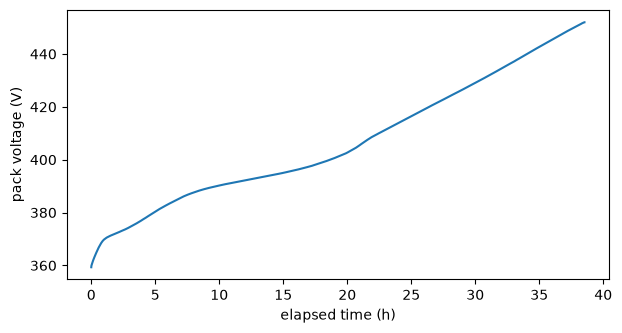

In [4]:
ax = frame.plot(x='time_h', y='U', legend=False, figsize=(7, 3.5))
ax.set_xlabel('elapsed time (h)')
ax.set_ylabel('pack voltage (V)')
plt.show()

Pack voltage rises steadily through the slow 8 A charge.